In [1]:
import subprocess
from ultralytics import YOLO
from pathlib import Path

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/accenture2/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:


# Dataset slug and output directory
DATASET = "vencerlanz09/taco-dataset-yolo-format"
OUT_DIR = Path("taco_dataset")

def download_dataset():
    """Download and unzip dataset using kaggle CLI."""
    if not OUT_DIR.exists():
        OUT_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "kaggle", "datasets", "download",
        "-d", DATASET,
        "-p", str(OUT_DIR),
        "--unzip"
    ], check=True)

download_dataset()


Traceback (most recent call last):
  File "/home/accenture2/trashdetector/GarbageDetector/myenv/bin/kaggle", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/home/accenture2/trashdetector/GarbageDetector/myenv/lib/python3.12/site-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/accenture2/trashdetector/GarbageDetector/myenv/lib/python3.12/site-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/accenture2/trashdetector/GarbageDetector/myenv/lib/python3.12/site-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


CalledProcessError: Command '['kaggle', 'datasets', 'download', '-d', 'vencerlanz09/taco-dataset-yolo-format', '-p', 'taco_dataset', '--unzip']' returned non-zero exit status 1.

In [5]:
OUT_DIR = Path("taco_dataset")
def train():
    """Train YOLO11n model on the dataset's data.yaml."""
    data_yaml = next(OUT_DIR.rglob("data.yaml"))  # find data.yaml inside dataset
    model = YOLO("yolo11n.pt")  # load YOLO11n
    model.train(data=str(data_yaml), epochs=100, imgsz=640, batch=32)
    
train()

Ultralytics 8.3.203 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=taco_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl


image 1/1 /home/accenture2/trashdetector/GarbageDetector/WhatsApp Image 2025-09-14 at 22.50.07.jpeg: 640x384 1 Bottle cap, 16.1ms
Speed: 1.9ms preprocess, 16.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)


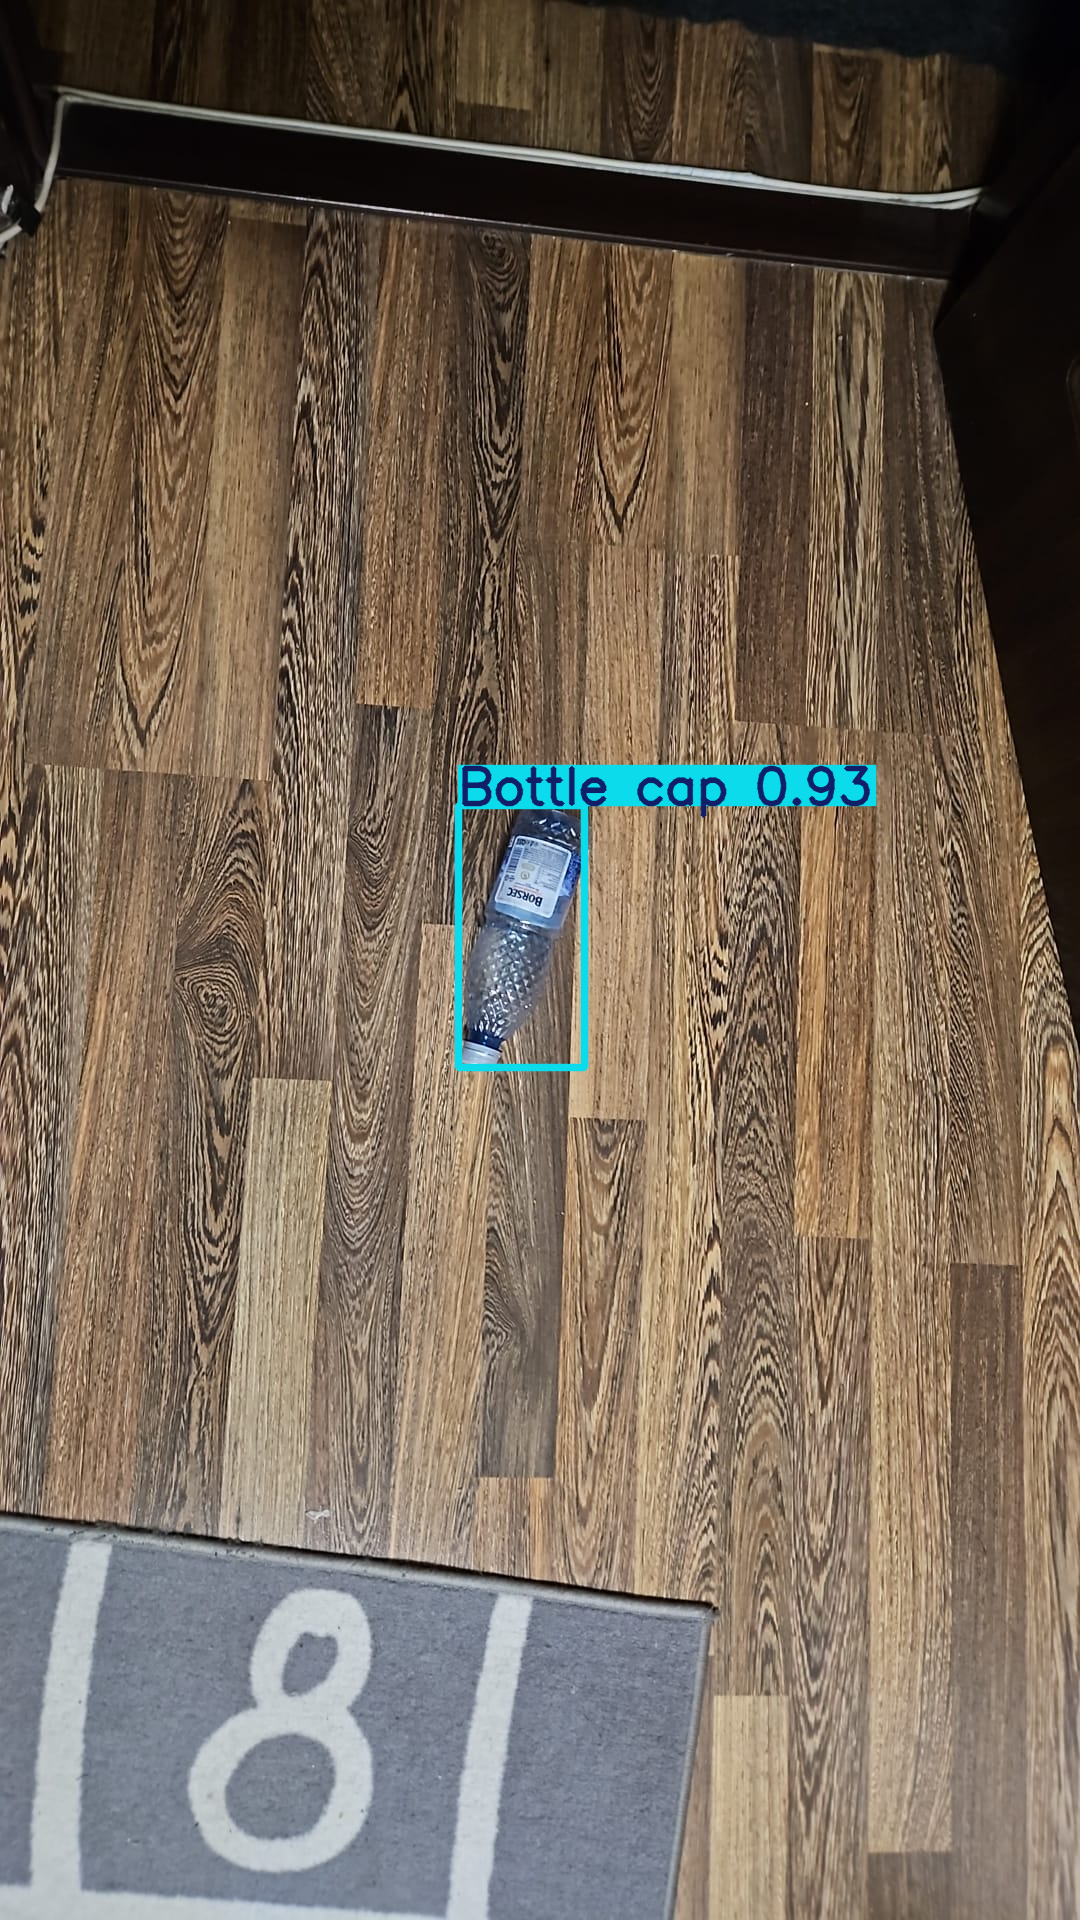

In [18]:
# Load the trained model
model = YOLO("runs/detect/train2/weights/best.pt")  # or last.pt, or any epochX.pt

# Predict on a single image
results = model("WhatsApp Image 2025-09-14 at 22.50.07.jpeg")

# Show the predictions
results[0].show()

# Save the predictions to disk
#results.save("runs/predict/")

In [19]:
model = YOLO("runs/detect/train2/weights/best.pt")

# Export to TensorFlow Lite
model.export(format="tflite")

Ultralytics 8.3.203 🚀 Python-3.12.3 torch-2.8.0+cu128 CPU (Intel Core i9-14900K)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,585,662 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 22, 8400) (5.2 MB)


E0000 00:00:1759246957.710752    9691 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759246957.727767    9691 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759246957.851689    9691 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759246957.851712    9691 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759246957.851713    9691 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759246957.851714    9691 computation_placer.cc:177] computation placer already registered. Please check linka

requirements: Ultralytics requirements ['tf_keras<=2.19.0', 'sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/151.2 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 133.1/151.2 kB 4.0 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.7 MB ? eta -:--:--
   ━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.7 MB 10.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/1.7 MB 9.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 1.0/1.7 MB 10.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━ 1.4/1.7 MB 10.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 10.7 MB/s eta 0:00

I0000 00:00:1759247032.468083    9691 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12853 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1759247034.462753    9691 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at 'runs/detect/train2/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 22, 8400), dtype=tf.float32, name=None)
Captures:
  137728052787728: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  137728052787536: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  137728052788880: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  137725953638864: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  137728052788112: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  137725953643088: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  137725953642512: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.float32, name=None)
  137725953643280: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  137725953643856: TensorSpec(shape=(4,), dtype=tf.int64, name=None)
  13772595364

I0000 00:00:1759247039.733546    9691 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1759247039.733717    9691 single_machine.cc:374] Starting new session
I0000 00:00:1759247039.734187    9691 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12853 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9
W0000 00:00:1759247040.110969    9691 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1759247040.111021    9691 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1759247040.976268    9691 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1759247040.976464    9691 single_machine.cc:374] Starting new session
I0000 00:00:1759247040.976978    9691 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12853 MB memory:  -> 

TensorFlow SavedModel: export success ✅ 85.0s, saved as 'runs/detect/train2/weights/best_saved_model' (26.2 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as 'runs/detect/train2/weights/best_saved_model/best_float32.tflite' (10.4 MB)

Export complete (85.1s)
Results saved to /home/accenture2/trashdetector/GarbageDetector/runs/detect/train2/weights
Predict:         yolo predict task=detect model=runs/detect/train2/weights/best_saved_model/best_float32.tflite imgsz=640  
Validate:        yolo val task=detect model=runs/detect/train2/weights/best_saved_model/best_float32.tflite imgsz=640 data=taco_dataset/data.yaml  
Visualize:       https://netron.app


'runs/detect/train2/weights/best_saved_model/best_float32.tflite'